<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Controls/E_20_238_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Controls

# Task#1
Twin rotor system dynamic model
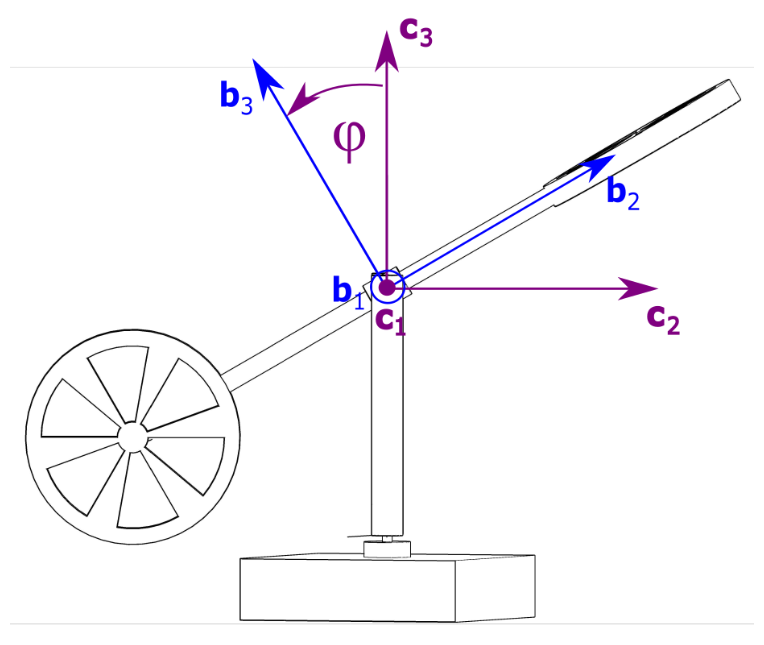

Show that the twin rotor system shown above can be modelled by

$$ \dot{R} = \widehat{\omega}R, $$
$$ \dot{\pi} = \tau^e + \tau^u, $$

where

$$ \omega = (\mathbb{I}^R)^{-1}\pi, $$

Here we have split the force and control moments into unmanipulatable and manipulatable (control) part. The manipulatable (control) part will be denoted by a superscript $u$ and takes the form

$$ \tau^u = R \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} \cos \alpha & -\cos \beta \\ \sin \alpha & -\sin \beta \end{bmatrix} \begin{bmatrix} u_1 \\ u_2 \end{bmatrix} $$

and the constraint moment that prevents the rotation of the device about $\mathbb{b}_2$ axis is

$$ \tau^e = R \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix} $$

with $T_2$ given by

$$ T_2 = e_2^T (\Omega \times \mathbb{I}\Omega + \mathbb{I}\dot{\Omega})$$

where $\Omega = R^T \omega$.

In [6]:
import numpy as np
import scipy as sp
from scipy.integrate import odeint
import math
from numpy import linalg
import sympy
from sympy import symbols
from sympy import *

import plotly.graph_objects as go
import plotly.express as px
from sympy.physics.mechanics import dynamicsymbols, init_vprinting
from IPython.display import display, Math, Latex

# Install the simulation helpers
!pip install --quiet "git+https://github.com/mugalan/classical-mechanics-from-a-geometric-point-of-view.git#egg=rigid-body-sim"
import sims
mr = sims.RigidBodySim()

alpha, theta, phi, gamma, R, Omega, I = dynamicsymbols("alpha, theta, phi,gamma, R, Omega, I")
init_vprinting
t, I_1, I_2, I_3, l= symbols('t, I_1, I_2, I_3, l')
init_vprinting()

dtheta = theta.diff(t);ddtheta = dtheta.diff(t)
dalpha = alpha.diff(t);ddalpha = dalpha.diff(t)
dgamma = gamma.diff(t);ddamma = dgamma.diff(t)
dphi = phi.diff(t);ddphi = dphi.diff(t)


R1_phi = Matrix([[1, 0, 0],[0, cos(phi), -sin(phi)],[0, sin(phi),cos(phi)]])
R3_alpha = Matrix([[cos(alpha),-sin(alpha),0],[sin(alpha),cos(alpha),0],[0,0,1]])
R1_gamma = Matrix([[1, 0, 0],[0, cos(gamma), -sin(gamma)],[0, sin(gamma),cos(gamma)]])
R3_theta = Matrix([[cos(theta),-sin(theta),0],[sin(theta),cos(theta),0],[0,0,1]])

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
